In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")


Libraries loaded successfully!


# **step 1:data collection**

In [8]:


np.random.seed(42)

n = 100

data = {
    "Student_ID": range(1, n + 1),
    "Study_Hours": np.random.randint(1, 10, n),
    "Attendance": np.random.randint(50, 101, n),
    "Previous_Marks": np.random.randint(40, 96, n),
    "Assignments": np.random.randint(3, 11, n),
    "Internal_Marks": np.random.randint(40, 96, n)
}

df = pd.DataFrame(data)

print("Dataset created successfully!")

Dataset created successfully!


In [5]:
df.head()

,Student_ID,Study_Hours,Attendance,Previous_Marks,Assignments,Internal_Marks
0,1,7,84,94,3,56
1,2,4,86,43,8,79
2,3,8,96,94,7,72
3,4,5,63,50,10,48
4,5,7,52,95,6,82


In [7]:


df.shape

(100, 6)

# **step2: data preprocessing**

In [10]:


df.isnull().sum()

,0
Student_ID,0
Study_Hours,0
Attendance,0
Previous_Marks,0
Assignments,0
Internal_Marks,0


In [11]:


score = (
    df["Study_Hours"] * 3
    + df["Attendance"] * 0.2
    + df["Previous_Marks"] * 0.3
    + df["Assignments"] * 2
    + df["Internal_Marks"] * 0.3
)

df["Final_Result"] = np.where(
    score >= score.median(),
    "Pass",
    "Fail"
)

print("Final_Result column created successfully!")

Final_Result column created successfully!


In [12]:


df.head()

,Student_ID,Study_Hours,Attendance,Previous_Marks,Assignments,Internal_Marks,Final_Result
0,1,7,84,94,3,56,Pass
1,2,4,86,43,8,79,Fail
2,3,8,96,94,7,72,Pass
3,4,5,63,50,10,48,Fail
4,5,7,52,95,6,82,Pass


In [13]:


df["Final_Result"].value_counts()

,count
Final_Result,
Pass,50
Fail,50


In [14]:


df["Final_Result"] = df["Final_Result"].map({
    "Pass": 1,
    "Fail": 0
})

print("Pass/Fail converted to 1/0 successfully!")

Pass/Fail converted to 1/0 successfully!


In [16]:


df["Final_Result"].head(10)

,Final_Result
0,1
1,0
2,1
3,0
4,1
5,0
6,1
7,1
8,0
9,1


**Select Features and Target**

In [17]:


X = df[[
    "Study_Hours",
    "Attendance",
    "Previous_Marks",
    "Assignments",
    "Internal_Marks"
]]

y = df["Final_Result"]

print("Features and target selected successfully!")

Features and target selected successfully!


**Split data into training and testing sets**


In [18]:


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (80, 5)
Testing data: (20, 5)


In [19]:


from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [20]:
y_pred = model.predict(X_test)

print("Predictions made successfully!")

Predictions made successfully!


In [21]:


comparison = pd.DataFrame({
    "Actual_Result": y_test.values,
    "Predicted_Result": y_pred
})

comparison

,Actual_Result,Predicted_Result
0,1,1
1,1,1
2,1,1
3,1,1
4,0,0
5,0,0
6,0,0
7,1,1
8,0,0
9,0,0


**Check Accuracy**

In [22]:


from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.9
Accuracy Percentage: 90.0 %


**Calculate Precision, Recall and F1-score**

In [23]:
# Calculate Precision, Recall and F1-score

from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.9
Recall: 0.9
F1-score: 0.9


confusion matrix

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[9 1]
 [1 9]]


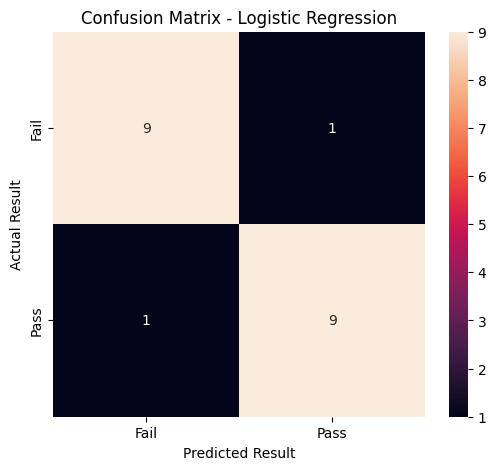

In [25]:
# Visualize the confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.xlabel("Predicted Result")
plt.ylabel("Actual Result")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

decision tree model


In [26]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(random_state=42)

decision_tree.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [27]:
dt_pred = decision_tree.predict(X_test)

print("Decision Tree predictions made successfully!")

Decision Tree predictions made successfully!


 Calculate Decision Tree accuracy

In [28]:
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree Accuracy Percentage:", dt_accuracy * 100, "%")

Decision Tree Accuracy: 0.75
Decision Tree Accuracy Percentage: 75.0 %


In [29]:
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("Decision Tree Precision:", dt_precision)
print("Decision Tree Recall:", dt_recall)
print("Decision Tree F1-score:", dt_f1)

Decision Tree Precision: 0.6923076923076923
Decision Tree Recall: 0.9
Decision Tree F1-score: 0.782608695652174


Create Decision Tree confusion matrix

In [30]:
dt_cm = confusion_matrix(y_test, dt_pred)

print("Decision Tree Confusion Matrix:")
print(dt_cm)

Decision Tree Confusion Matrix:
[[6 4]
 [1 9]]


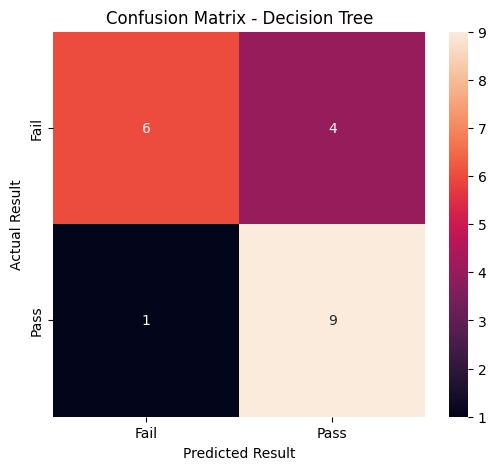

In [31]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.xlabel("Predicted Result")
plt.ylabel("Actual Result")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

Predict the result of a new student


In [34]:
study_hours = float(input("Enter Study Hours: "))
attendance = float(input("Enter Attendance (%): "))
previous_marks = float(input("Enter Previous Marks: "))
assignments = float(input("Enter Assignment Score: "))
internal_marks = float(input("Enter Internal Marks: "))

new_student = pd.DataFrame([{
    "Study_Hours": study_hours,
    "Attendance": attendance,
    "Previous_Marks": previous_marks,
    "Assignments": assignments,
    "Internal_Marks": internal_marks
}])

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("\nPredicted Result: PASS")
else:
    print("\nPredicted Result: FAIL")

Enter Study Hours: 6
Enter Attendance (%): 85
Enter Previous Marks: 75
Enter Assignment Score: 8
Enter Internal Marks: 78

Predicted Result: PASS


Identify students at risk of failing


In [35]:
all_predictions = model.predict(X)

df["Predicted_Result"] = all_predictions

at_risk_students = df[df["Predicted_Result"] == 0]

print("Number of students at risk:", len(at_risk_students))

Number of students at risk: 51


In [36]:


at_risk_students[[
    "Student_ID",
    "Study_Hours",
    "Attendance",
    "Previous_Marks",
    "Assignments",
    "Internal_Marks",
    "Predicted_Result"
]]

,Student_ID,Study_Hours,Attendance,Previous_Marks,Assignments,Internal_Marks,Predicted_Result
1,2,4,86,43,8,79,0
3,4,5,63,50,10,48,0
5,6,3,50,56,10,93,0
8,9,5,63,44,9,68,0
12,13,3,64,61,3,74,0
15,16,2,91,55,5,63,0
16,17,8,62,72,5,52,0
17,18,6,100,48,8,46,0
18,19,2,81,45,9,75,0
20,21,1,98,68,8,59,0


Visualize predicted Pass/Fail results

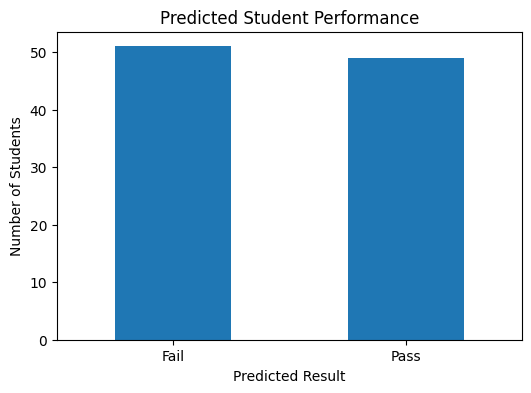

In [37]:


result_counts = df["Predicted_Result"].map({
    0: "Fail",
    1: "Pass"
}).value_counts()

plt.figure(figsize=(6, 4))

result_counts.plot(kind="bar")

plt.xlabel("Predicted Result")
plt.ylabel("Number of Students")
plt.title("Predicted Student Performance")
plt.xticks(rotation=0)

plt.show()

Study Hours vs Previous Marks

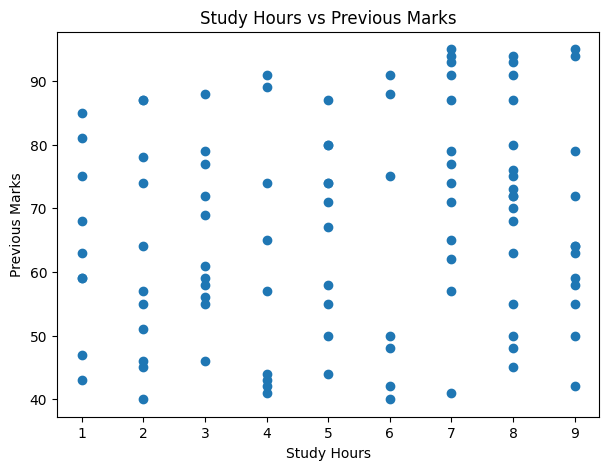

In [38]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["Study_Hours"],
    df["Previous_Marks"]
)

plt.xlabel("Study Hours")
plt.ylabel("Previous Marks")
plt.title("Study Hours vs Previous Marks")

plt.show()

Attendance vs Previous Marks

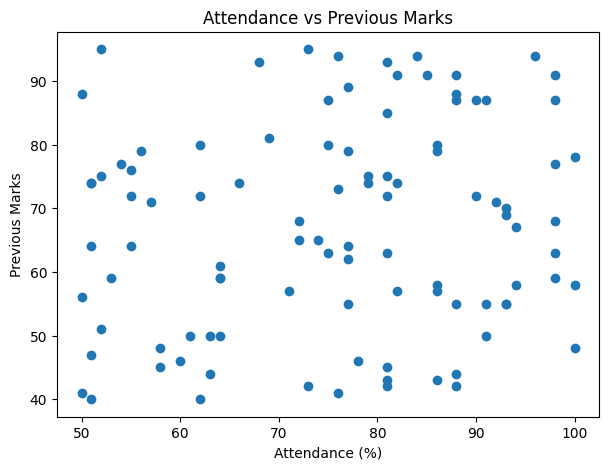

In [39]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["Attendance"],
    df["Previous_Marks"]
)

plt.xlabel("Attendance (%)")
plt.ylabel("Previous Marks")
plt.title("Attendance vs Previous Marks")

plt.show()

Correlation Heatmap

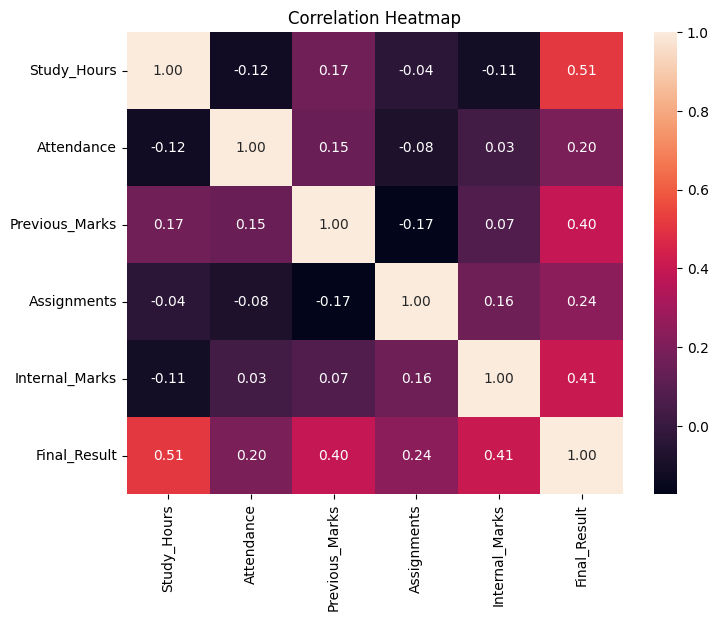

In [40]:
plt.figure(figsize=(8, 6))

correlation = df[
    [
        "Study_Hours",
        "Attendance",
        "Previous_Marks",
        "Assignments",
        "Internal_Marks",
        "Final_Result"
    ]
].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Normalize the Numerical Features

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data normalization completed successfully!")

Data normalization completed successfully!


Train Logistic Regression with Normalized Data

In [42]:


scaled_model = LogisticRegression()

scaled_model.fit(X_train_scaled, y_train)

print("Scaled Logistic Regression model trained successfully!")

Scaled Logistic Regression model trained successfully!


Make Predictions Using the Normalized Model

In [43]:


scaled_pred = scaled_model.predict(X_test_scaled)

print("Predictions completed successfully!")

Predictions completed successfully!


 Accuracy of normalized Logistic Regression

In [44]:
scaled_accuracy = accuracy_score(y_test, scaled_pred)

print("Normalized Logistic Regression Accuracy:", scaled_accuracy)
print("Accuracy Percentage:", scaled_accuracy * 100, "%")


Normalized Logistic Regression Accuracy: 0.9
Accuracy Percentage: 90.0 %


Evaluation of normalized Logistic Regression

In [45]:


scaled_precision = precision_score(y_test, scaled_pred)
scaled_recall = recall_score(y_test, scaled_pred)
scaled_f1 = f1_score(y_test, scaled_pred)

print("Precision:", scaled_precision)
print("Recall:", scaled_recall)
print("F1-score:", scaled_f1)

Precision: 0.9
Recall: 0.9
F1-score: 0.9


Confusion Matrix for Normalized Model

In [46]:
scaled_cm = confusion_matrix(y_test, scaled_pred)

print("Confusion Matrix:")
print(scaled_cm)

Confusion Matrix:
[[9 1]
 [1 9]]


Confusion Matrix Visualization

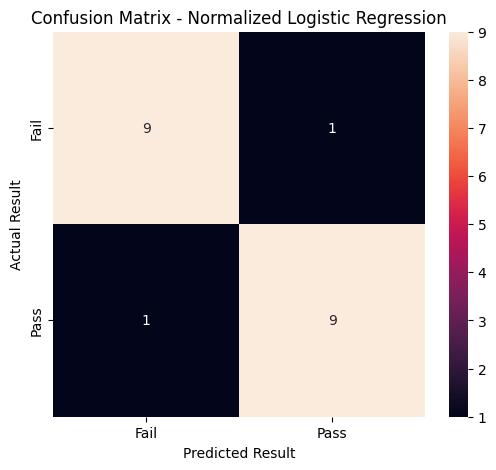

In [47]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    scaled_cm,
    annot=True,
    fmt="d",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.xlabel("Predicted Result")
plt.ylabel("Actual Result")
plt.title("Confusion Matrix - Normalized Logistic Regression")

plt.show()

Model Accuracy Comparison

In [49]:

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Normalized Logistic Regression"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        scaled_accuracy
    ]
})

model_results["Accuracy Percentage"] = model_results["Accuracy"] * 100

model_results

,Model,Accuracy,Accuracy Percentage
0,Logistic Regression,0.90,90.0
1,Decision Tree,0.75,75.0
2,Normalized Logistic Regression,0.90,90.0


Model Accuracy Comparison Graph

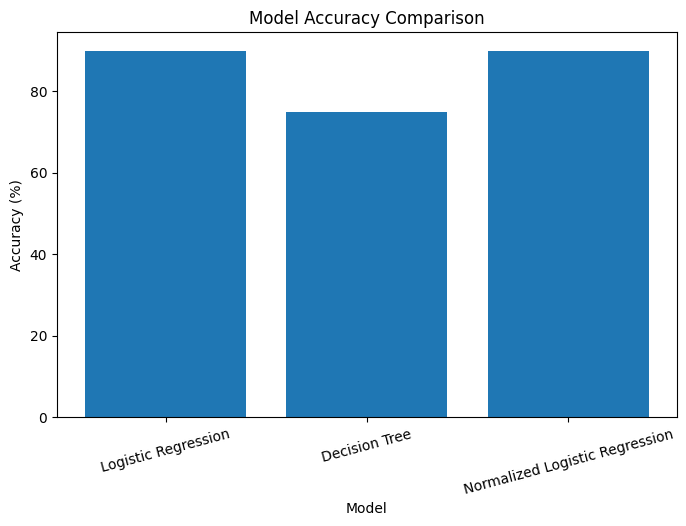

In [50]:


plt.figure(figsize=(8, 5))

plt.bar(
    model_results["Model"],
    model_results["Accuracy Percentage"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)

plt.show()

Final Model Evaluation Summary

In [51]:

final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy
    ],
    "Precision": [
        precision,
        dt_precision
    ],
    "Recall": [
        recall,
        dt_recall
    ],
    "F1_Score": [
        f1,
        dt_f1
    ]
})

final_results

,Model,Accuracy,Precision,Recall,F1_Score
0,Logistic Regression,0.90,0.900000,0.9,0.900000
1,Decision Tree,0.75,0.692308,0.9,0.782609


Final At-Risk Student Count

In [52]:
print("Total Students:", len(df))
print("Students At Risk:", len(at_risk_students))
print("Students Not At Risk:", len(df) - len(at_risk_students))

Total Students: 100
Students At Risk: 51
Students Not At Risk: 49


In [54]:


df.to_excel("student_performance_results.xlsx", index=False)

print("Excel file saved successfully!")

Excel file saved successfully!


In [55]:
from google.colab import files

files.download("student_performance_results.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Final Project Summary

In [56]:
print("STUDENT PERFORMANCE PREDICTION SYSTEM")
print("--------------------------------------")
print("Total Students:", len(df))
print("Students At Risk:", len(at_risk_students))
print("Students Not At Risk:", len(df) - len(at_risk_students))
print("Logistic Regression Accuracy:", accuracy * 100, "%")
print("Decision Tree Accuracy:", dt_accuracy * 100, "%")
print("Normalized Logistic Regression Accuracy:", scaled_accuracy * 100, "%")
print("--------------------------------------")
print("Project completed successfully!")

STUDENT PERFORMANCE PREDICTION SYSTEM
--------------------------------------
Total Students: 100
Students At Risk: 51
Students Not At Risk: 49
Logistic Regression Accuracy: 90.0 %
Decision Tree Accuracy: 75.0 %
Normalized Logistic Regression Accuracy: 90.0 %
--------------------------------------
Project completed successfully!
